# MKA-MLF, Lab_08 - RNN

Recurrent Neural Networks, are a class of artificial neural networks designed to recognize patterns in sequences of data, such as text, genomes, handwriting, or spoken words. Unlike traditional neural networks, which assume all inputs (and outputs) are independent of each other, RNNs are designed to recognize sequential or temporal patterns, making them especially suited for tasks like language modeling, speech recognition, and time series prediction.

## Exercise 1 - Time Series Forecasting

### 1.0 Import Libraries

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Flatten, SimpleRNN
from keras.optimizers import Adam

### 1.1 Generating dataset

In [43]:
def generate_time_series(batch_size, n_steps):
  freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
  time = np.linspace(0,1,n_steps)

  series = 0.5 * np.sin((time - offsets1) * (freq1*10 + 10))
  series += 0.2 * np.sin((time - offsets2) * (freq2*20 + 20))
  series += 0.1 * (np.random.rand(batch_size, n_steps)- 0.5)
  return series[..., np.newaxis].astype(np.float32)

In [44]:
data_size = 10000
n_steps = 50
np.random.seed(0)

series = generate_time_series(data_size, n_steps + 1)

### 1.2 Train/Valid/Test split

In [45]:
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

In [46]:
no_training_epochs = 5

### 1.3 Data examination

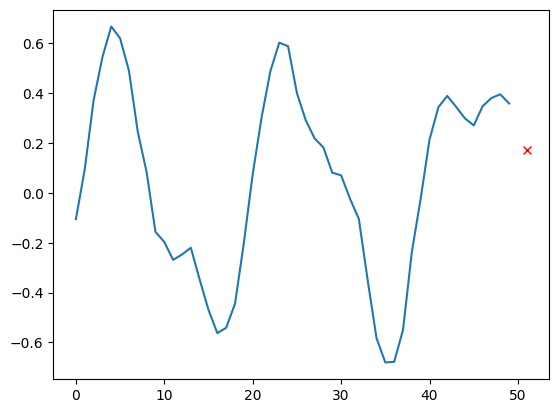

In [47]:
plt.figure()
plt.plot(X_train[0])
plt.plot(n_steps+1, y_train[0], 'rx')

### 1.4 Simple Linear model

In [48]:
# Model definition
model_linear = Sequential()
model_linear.add(Flatten(input_shape=(50,1)))
model_linear.add(Dense(1, activation = None))

In [49]:
# Model building

learning_rate = 0.001
optimizer = Adam(learning_rate)
model_linear.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mean_squared_error'])

In [50]:
model_linear.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [51]:
# Model training

history_linear = model_linear.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0643 - mean_squared_error: 0.0643 - val_loss: 0.0232 - val_mean_squared_error: 0.0232
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0156 - mean_squared_error: 0.0156 - val_loss: 0.0107 - val_mean_squared_error: 0.0107
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0094 - mean_squared_error: 0.0094 - val_loss: 0.0079 - val_mean_squared_error: 0.0079
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0076 - mean_squared_error: 0.0076 - val_loss: 0.0067 - val_mean_squared_error: 0.0067
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0066 - mean_squared_error: 0.0066 - val_loss: 0.0060 - val_mean_squared_error: 0.0060


In [52]:
def plot_function(history):
  plt.figure()

  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='validation_loss')
  plt.legend()
  plt.grid()
  plt.xlim([0,no_training_epochs-1])
  plt.xlabel('epochs')

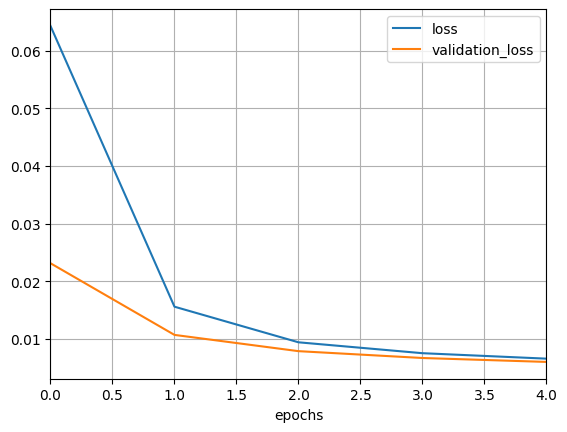

In [53]:
plot_function(history_linear)

In [54]:
score = model_linear.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.005808454472571611
Test MSE:  0.005808454472571611


### 1.5 Simple RNN Model

In [55]:
model_simple_rnn = Sequential()
model_simple_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

In [56]:
learning_rate_simple_rnn = 0.001
optimizer_simple_rnn = Adam(learning_rate_simple_rnn)
model_simple_rnn.compile(loss='mean_squared_error', optimizer=optimizer_simple_rnn, metrics=['mean_squared_error'])

In [57]:
history_simple_rnn = model_simple_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4454 - mean_squared_error: 0.4454 - val_loss: 0.4233 - val_mean_squared_error: 0.4233
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3975 - mean_squared_error: 0.3975 - val_loss: 0.3791 - val_mean_squared_error: 0.3791
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3532 - mean_squared_error: 0.3532 - val_loss: 0.3354 - val_mean_squared_error: 0.3354
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3106 - mean_squared_error: 0.3106 - val_loss: 0.2931 - val_mean_squared_error: 0.2931
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2700 - mean_squared_error: 0.2700 - val_loss: 0.2532 - val_mean_squared_error: 0.2532


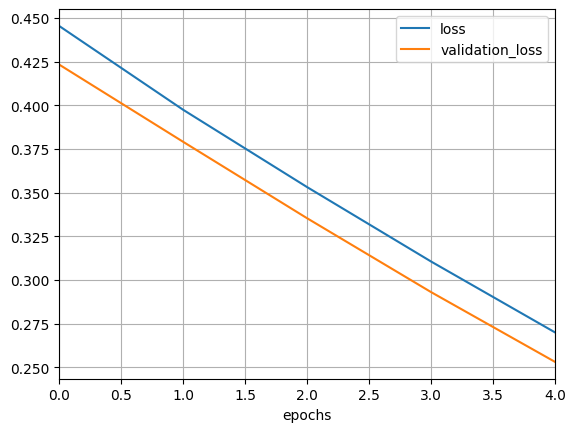

In [58]:
plot_function(history_simple_rnn)

### 1.5 Deep RNN Model

In [59]:
model_deep_rnn = Sequential()
model_deep_rnn.add(SimpleRNN(20, return_sequences = True, input_shape=[50, 1]))
model_deep_rnn.add(SimpleRNN(20, return_sequences = True))
model_deep_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

In [60]:
learning_rate_deep_rnn = 0.001
optimizer_deep_rnn = Adam(learning_rate_deep_rnn)
model_deep_rnn.compile(loss='mean_squared_error', optimizer=optimizer_deep_rnn, metrics=['mean_squared_error'])

In [61]:
history_deep_rnn = model_deep_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.0119 - mean_squared_error: 0.0119 - val_loss: 0.0042 - val_mean_squared_error: 0.0042
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0038 - mean_squared_error: 0.0038 - val_loss: 0.0035 - val_mean_squared_error: 0.0035
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0035 - mean_squared_error: 0.0035 - val_loss: 0.0033 - val_mean_squared_error: 0.0033
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0033 - mean_squared_error: 0.0033 - val_loss: 0.0033 - val_mean_squared_error: 0.0033
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0032 - mean_squared_error: 0.0032 - val_loss: 0.0030 - val_mean_squared_error: 0.0030


In [62]:
score = model_deep_rnn.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.0032234536483883858
Test MSE:  0.0032234536483883858


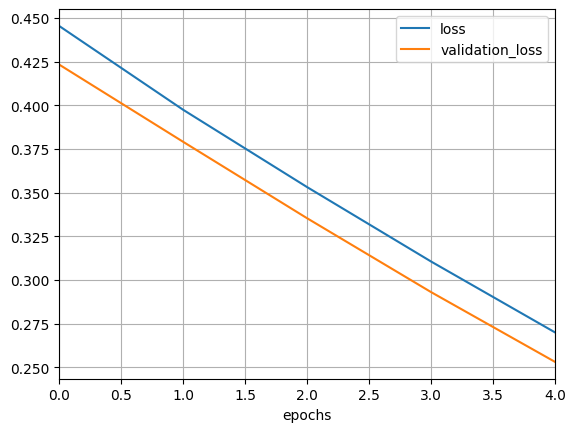

In [63]:
plot_function(history_simple_rnn)

## Exercise 2 - The movie review




Based on the written rewiev, classify if the movie if good or bad

### 2.0 - Import libraries

In [65]:
import keras
import numpy as np
from keras.models import Sequential
from keras.layers import LSTM, Dense, Embedding, SimpleRNN, GRU
from keras.utils import pad_sequences
import matplotlib.pyplot as plt
from keras.optimizers import Adam

### 2.1 - Load dataset

In [76]:
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=1000)

### 2.2 - Dataset examination

In [78]:
word_index = keras.datasets.imdb.get_word_index()
id_to_word = {id_ + 3:word for word, id_ in word_index.items()}
for id_, token in enumerate(("<pad>", "<sos>", "<unk>")):
  id_to_word[id_] = token

In [79]:
single_sequence = " ".join([id_to_word[id_] for id_ in X_train[0][:]])

In [80]:
single_sequence

'<sos> this film was just brilliant casting <unk> <unk> story direction <unk> really <unk> the part they played and you could just imagine being there robert <unk> is an amazing actor and now the same being director <unk> father came from the same <unk> <unk> as myself so i loved the fact there was a real <unk> with this film the <unk> <unk> throughout the film were great it was just brilliant so much that i <unk> the film as soon as it was released for <unk> and would recommend it to everyone to watch and the <unk> <unk> was amazing really <unk> at the end it was so sad and you know what they say if you <unk> at a film it must have been good and this definitely was also <unk> to the two little <unk> that played the <unk> of <unk> and paul they were just brilliant'

In [81]:
max_length = 150  # Define the maximum length of a review
X_train = pad_sequences(X_train, maxlen=max_length, padding='post', truncating='post', value=0)
X_test = pad_sequences(X_test, maxlen=max_length, padding='post', truncating='post', value=0)

In [85]:
embed_size = 128
vocabulary_size = 1000

model = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size,
                           input_shape=[None]),
    keras.layers.SimpleRNN(128, return_sequences=True),
    keras.layers.SimpleRNN(128),
    keras.layers.Dense(1, activation='sigmoid')
    ])


In [87]:
optimizer = Adam(learning_rate = 0.001)

In [88]:
model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])

In [91]:
history = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 77ms/step - accuracy: 0.4979 - loss: 0.6960 - val_accuracy: 0.5062 - val_loss: 0.6981
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 71ms/step - accuracy: 0.4983 - loss: 0.6965 - val_accuracy: 0.4938 - val_loss: 0.6932
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 75ms/step - accuracy: 0.4956 - loss: 0.6965 - val_accuracy: 0.5062 - val_loss: 0.7001
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 72ms/step - accuracy: 0.4971 - loss: 0.6965 - val_accuracy: 0.4938 - val_loss: 0.6938
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - accuracy: 0.4967 - loss: 0.6957 - val_accuracy: 0.5062 - val_loss: 0.6931


In [93]:
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test accuracy: ', score[1]*100, "%")

Test loss: 0.6932193636894226
Test accuracy:  50.0 %


TASK: Modify structure, change the core of the network from RNN to LTSM and GRU. Compare the results

In [94]:
#LSTM
model_lstm = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size, input_shape=[None]),
    keras.layers.LSTM(128, return_sequences=True),
    keras.layers.LSTM(128),
    keras.layers.Dense(1, activation='sigmoid')
])

model_lstm.compile(loss="binary_crossentropy", optimizer=Adam(learning_rate=0.001), metrics=["accuracy"])
history_lstm = model_lstm.fit(X_train, y_train, epochs=5, validation_split=0.2)
score_lstm = model_lstm.evaluate(X_test, y_test, verbose=0)
print('LSTM Test loss:', score_lstm[0])
print(f'LSTM Test accuracy: ', score_lstm[1] * 100, "%")


Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 207s 328ms/step - accuracy: 0.5577 - loss: 0.6767 - val_accuracy: 0.6300 - val_loss: 0.6463
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 194s 311ms/step - accuracy: 0.5202 - loss: 0.6911 - val_accuracy: 0.5006 - val_loss: 0.6932
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 193s 309ms/step - accuracy: 0.5713 - loss: 0.6681 - val_accuracy: 0.7574 - val_loss: 0.5286
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 194s 311ms/step - accuracy: 0.7951 - loss: 0.4422 - val_accuracy: 0.8138 - val_loss: 0.4110
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 202s 311ms/step - accuracy: 0.8286 - loss: 0.3862 - val_accuracy: 0.8198 - val_loss: 0.4002
LSTM Test loss: 0.38682234287261963
LSTM Test accuracy:  82.41599798202515 %


In [95]:
#GRU
model_gru = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size, input_shape=[None]),
    keras.layers.GRU(128, return_sequences=True),
    keras.layers.GRU(128),
    keras.layers.Dense(1, activation='sigmoid')
])

model_gru.compile(loss="binary_crossentropy", optimizer=Adam(learning_rate=0.001), metrics=["accuracy"])
history_gru = model_gru.fit(X_train, y_train, epochs=5, validation_split=0.2)
score_gru = model_gru.evaluate(X_test, y_test, verbose=0)
print('GRU Test loss:', score_gru[0])
print(f'GRU Test accuracy: ', score_gru[1] * 100, "%")

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 144s 228ms/step - accuracy: 0.5940 - loss: 0.6416 - val_accuracy: 0.7700 - val_loss: 0.4838
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 144s 230ms/step - accuracy: 0.8140 - loss: 0.4041 - val_accuracy: 0.8360 - val_loss: 0.3796
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 227ms/step - accuracy: 0.8475 - loss: 0.3447 - val_accuracy: 0.8214 - val_loss: 0.3939
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 141s 225ms/step - accuracy: 0.8587 - loss: 0.3222 - val_accuracy: 0.8306 - val_loss: 0.4088
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 143s 227ms/step - accuracy: 0.8694 - loss: 0.3002 - val_accuracy: 0.8232 - val_loss: 0.4063
GRU Test loss: 0.38418617844581604
GRU Test accuracy:  83.13599824905396 %


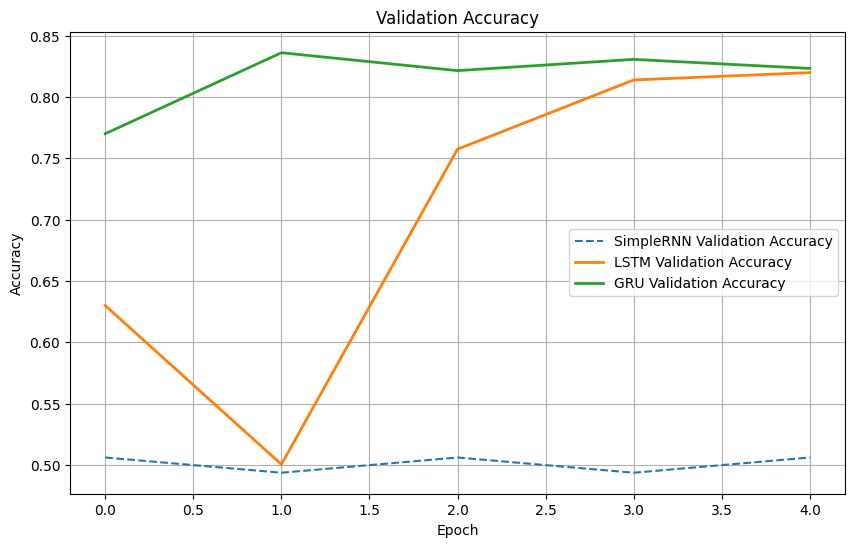

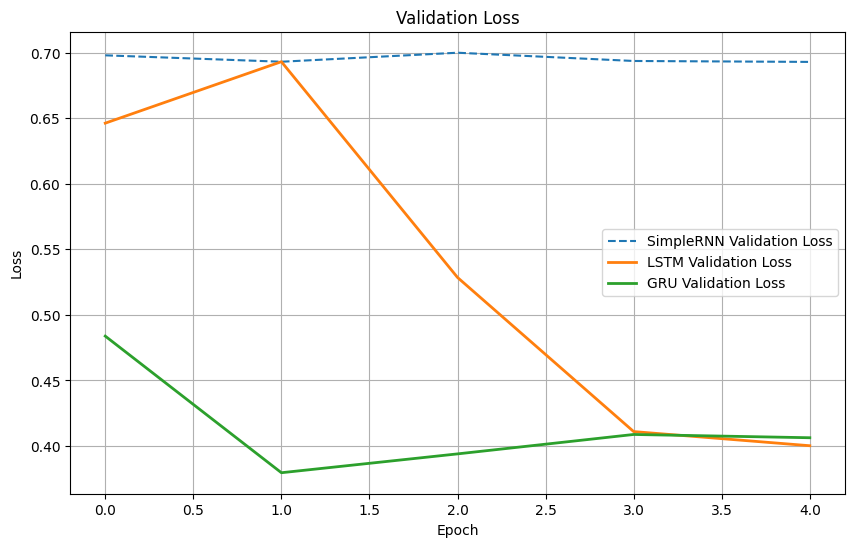

In [96]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['val_accuracy'], label='SimpleRNN Validation Accuracy', linestyle='--')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Validation Accuracy', linewidth=2)
plt.plot(history_gru.history['val_accuracy'], label='GRU Validation Accuracy', linewidth=2)
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(history.history['val_loss'], label='SimpleRNN Validation Loss', linestyle='--')
plt.plot(history_lstm.history['val_loss'], label='LSTM Validation Loss', linewidth=2)
plt.plot(history_gru.history['val_loss'], label='GRU Validation Loss', linewidth=2)
plt.title('Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()